In [2]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#  Load dataset
data = pd.read_csv(r"C:\Users\ADMIN\Documents\mini_project_guvi\project_diamond\regression.csv")
data.head()

,y,carat,volume,clarity,x,color,price_per_carat,price_inr
0,3.98,0.207014,38.202030,2,3.95,6,27.968908,480.566694
1,3.84,0.190620,34.505856,3,3.89,6,30.374301,480.566694
2,4.07,0.207014,38.076885,5,4.05,6,27.983657,480.820129
3,4.23,0.254642,46.724580,4,4.20,2,22.832547,482.572834
4,4.35,0.270027,51.917250,2,4.34,1,21.542691,482.820226


In [4]:
# Select features for clustering
features = ["y", "carat", "volume", "clarity", "x", "color", "price_per_carat"]
X = data[features]

# Scale all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# Silhouette Score to validate clusters
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")


K = 2, Silhouette Score = 0.4339
K = 3, Silhouette Score = 0.3484
K = 4, Silhouette Score = 0.2870
K = 5, Silhouette Score = 0.2701
K = 6, Silhouette Score = 0.2730
K = 7, Silhouette Score = 0.2839
K = 8, Silhouette Score = 0.2836
K = 9, Silhouette Score = 0.2884
K = 10, Silhouette Score = 0.2921


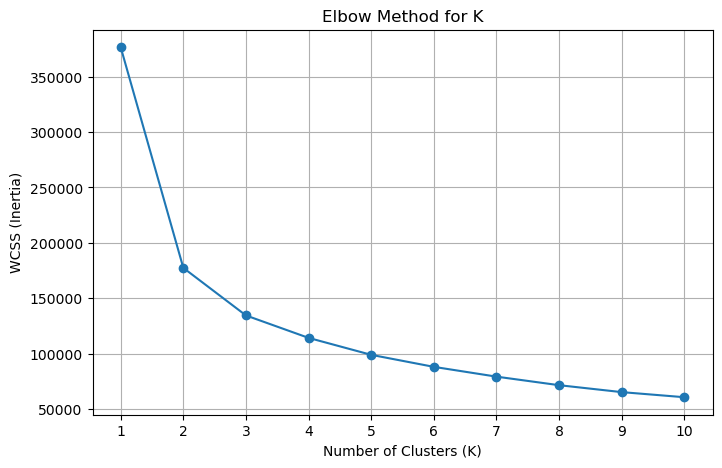

In [6]:
# K-Means Clustering with Elbow Method
wcss = []  # within-cluster sum of squares

# Test K = 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for K')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


Cluster
1    27829
0    25965
Name: count, dtype: int64


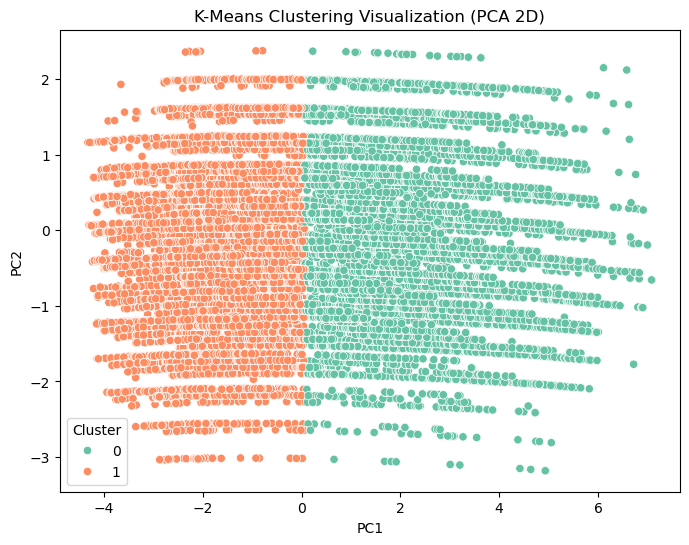

In [8]:
# Fit final K-Means model with K
optimal_k = 2 
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to original data
data['Cluster'] = cluster_labels

# Inspect cluster counts
print(data['Cluster'].value_counts())

# visualize clusters using first two principal components
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=cluster_labels, palette='Set2')
plt.title('K-Means Clustering Visualization (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()

In [10]:
import joblib
joblib.dump(kmeans, "best_kmeans_model.pkl")
print("K-Means model saved successfully as 'best_kmeans_model.pkl'")

K-Means model saved successfully as 'best_kmeans_model.pkl'


In [17]:
#  Group by clusters and calculate summary statistics
cluster_summary = data.groupby('Cluster').agg({
    'carat': 'mean',
    'price_inr': 'mean',
    'price_per_carat': 'mean',
    'volume': 'mean',
    'clarity': 'mean'    
}).round(2)

print("Cluster Summary:")
print(cluster_summary)


Cluster Summary:
         carat  price_inr  price_per_carat  volume  clarity
Cluster                                                    
0         0.76     716.06            11.61  192.41     3.38
1         0.36     579.07            20.49   71.23     4.68


In [19]:
# Assign descriptive cluster names based on characteristics
# Example approach: look at mean carat and price, then map names
cluster_name_mapping = {
    0: "Premium Heavy Diamonds",
    1: "Affordable Small Diamonds",
    2: "Mid-range Balanced Diamonds",
    3: "High-End Rare Diamonds"  # add or adjust based on your cluster analysis
}

# Create a new column for cluster names
data['Cluster_Name'] = data['Cluster'].map(cluster_name_mapping)

# Inspect results
data[['Cluster', 'Cluster_Name', 'carat', 'price_inr', 'price_per_carat', 'volume', 'clarity']].head()


,Cluster,Cluster_Name,carat,price_inr,price_per_carat,volume,clarity
0,1,Affordable Small Diamonds,0.207014,480.566694,27.968908,38.202030,2
1,1,Affordable Small Diamonds,0.190620,480.566694,30.374301,34.505856,3
2,1,Affordable Small Diamonds,0.207014,480.820129,27.983657,38.076885,5
3,1,Affordable Small Diamonds,0.254642,482.572834,22.832547,46.724580,4
4,1,Affordable Small Diamonds,0.270027,482.820226,21.542691,51.917250,2


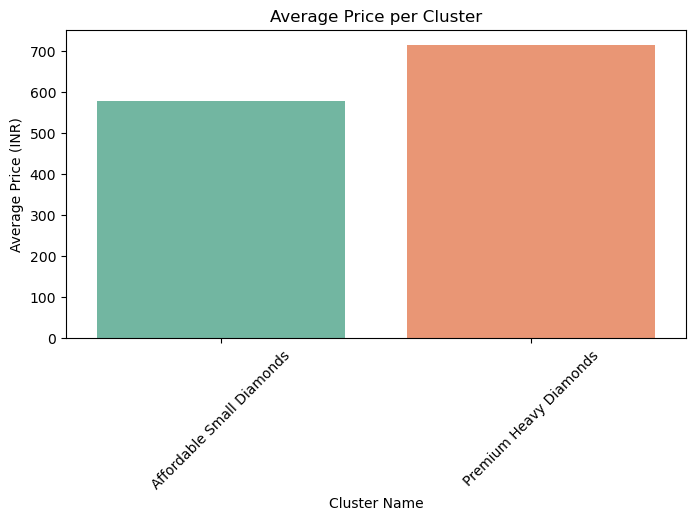

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

# Updated barplot syntax for Seaborn >=0.14
sns.barplot(
   x='Cluster_Name',
    y='price_inr',
    data=data,
    errorbar=None,        # replaces ci=None
    palette='Set2',
    hue='Cluster_Name',   # adds color distinction
    dodge=False           # prevents overlapping bars
)

plt.title("Average Price per Cluster")
plt.ylabel("Average Price (INR)")
plt.xlabel("Cluster Name")
plt.xticks(rotation=45)
plt.show()
